# ReAct on a local model: Gemma 4 31B (4-bit MLX)

[Yao et al., 2022](https://research.google/blog/react-synergizing-reasoning-and-acting-in-language-models/) call their pattern **ReAct**: the model interleaves *Thought*—free-form reasoning—with *Action*—a structured tool call. The runtime executes the action, returns an *Observation*, and the loop continues until the model emits a `Finish[answer]` action.

This notebook runs the loop locally on a Mac with **Gemma 4 31B (4-bit MLX)** — the multimodal variant, so the *same* checkpoint serves both text and vision tasks. Three text tasks (multi-hop QA, calculator math, date arithmetic) and three vision tasks (counting, receipt totals, focused inspection). All traces are shown verbatim, including failures.

Hardware budget: ~19 GB peak on an M2 Max, 15 tok/s, ~3 s per ReAct step.

## 1. Model + ReAct loop

We load Gemma 4 31B once and reuse it. `mlx_vlm.generate` accepts an empty image list for text-only prompts.

In [1]:
import time, re, datetime, ast, operator, math, textwrap
from pathlib import Path

from mlx_vlm import load as load_vlm, generate as vlm_generate
from mlx_vlm.prompt_utils import apply_chat_template
from mlx_vlm.utils import load_config

MODEL_ID = 'mlx-community/gemma-4-31b-it-4bit'
_state = {}

def get_model():
    if 'model' not in _state:
        t0 = time.time()
        _state['model'], _state['proc'] = load_vlm(MODEL_ID)
        _state['cfg'] = load_config(MODEL_ID)
        print(f'[load] {time.time()-t0:.1f}s')
    return _state['model'], _state['proc'], _state['cfg']

def llm(prompt: str, images=None, max_tokens=300):
    model, proc, cfg = get_model()
    images = images or []
    formatted = apply_chat_template(proc, cfg, prompt, num_images=len(images))
    out = vlm_generate(model, proc, formatted, image=images,
                       max_tokens=max_tokens, verbose=False)
    return out.text

In [2]:
def _strip_leaks(text):
    # Strip Gemma 4 template leaks (e.g. "<channel|>") and any hallucinated
    # *Observation* the model invents past its action.
    text = re.sub(r"<[^<>]*\|>", "", text)
    for marker in ("\nObservation", "\n观察结果", "\n观察"):
        idx = text.find(marker, 1)
        if idx > 0:
            text = text[:idx]
    return text.strip()

# Loose regex; we then filter matches by whether the name is a registered tool.
_ACTION_RE = re.compile(
    r"(?:^|\n)\s*(?:Action(?:\s*\d*)?:\s*)?(\w+)\s*\[(.*?)\]\s*(?:\n|$)",
    re.DOTALL,
)

def _find_action(out, valid_names):
    for m in _ACTION_RE.finditer(out):
        if m.group(1) in valid_names:
            return m
    return None

def react(question, tools, system, images=None,
          max_steps=6, max_tokens_per_step=420):
    """Minimal ReAct loop. tools is dict name->callable(arg_str)->str.

    Each step: append "Thought N:", generate, strip Observation hallucinations
    and template leaks, find the first Action[arg] whose tool name is one we
    know about, execute it, append the real Observation. Halts on Finish[answer].
    """
    valid = set(tools) | {"Finish"}
    trace = system.strip() + "\n\nQuestion: " + question.strip() + "\n"
    print(trace, end="")
    for step in range(1, max_steps + 1):
        prompt = trace + f"\nThought {step}:"
        out = llm(prompt, images=images, max_tokens=max_tokens_per_step)
        out = _strip_leaks(out)

        m = _find_action(out, valid)
        if not m:
            preview = out[:200].replace("\n", " | ")
            print(f"\n[step {step}: no recognised Action in: {preview!r}]")
            return None
        out = out[:m.end()]
        leading = "" if out.startswith("\n") else " "
        chunk = f"\nThought {step}:{leading}{out.rstrip()}"
        chunk = re.sub(r"^\nThought (\d+):\s*Thought \1:\s*", r"\nThought \1: ", chunk)
        print(chunk, end="")
        trace += chunk

        name, arg = m.group(1).strip(), m.group(2).strip()
        if name == "Finish":
            print(f"\n\n=> Final answer: {arg}")
            return arg
        try:
            obs = str(tools[name](arg))[:600]
        except Exception as e:
            obs = f"tool error: {type(e).__name__}: {e}"
        addition = f"\nObservation {step}: {obs}"
        print(addition, end="")
        trace += addition
    print("\n[max steps reached]")
    return None


## 2. Text tools

Three tiny tools — search, calc, today — enough to drive interesting behaviour.

In [3]:
import wikipedia
wikipedia.set_lang('en')

def tool_search(query: str) -> str:
    """Returns the first paragraph of the top Wikipedia hit, or a disambiguation list."""
    try:
        return wikipedia.summary(query, sentences=2, auto_suggest=True)
    except wikipedia.DisambiguationError as e:
        return 'disambiguation: ' + ', '.join(e.options[:6])
    except wikipedia.PageError:
        hits = wikipedia.search(query)[:5]
        return f'no exact page; nearest titles: {hits}'

_OPS = {ast.Add: operator.add, ast.Sub: operator.sub, ast.Mult: operator.mul,
        ast.Div: operator.truediv, ast.Pow: operator.pow, ast.USub: operator.neg,
        ast.Mod: operator.mod, ast.FloorDiv: operator.floordiv}
_FNS = {'sqrt': math.sqrt, 'log': math.log, 'log10': math.log10,
        'exp': math.exp, 'sin': math.sin, 'cos': math.cos, 'pi': math.pi,
        'round': round, 'abs': abs, 'min': min, 'max': max}
def _eval(node):
    if isinstance(node, ast.Constant): return node.value
    if isinstance(node, ast.BinOp):    return _OPS[type(node.op)](_eval(node.left), _eval(node.right))
    if isinstance(node, ast.UnaryOp):  return _OPS[type(node.op)](_eval(node.operand))
    if isinstance(node, ast.Call):
        fn = _FNS[node.func.id]
        return fn(*[_eval(a) for a in node.args])
    if isinstance(node, ast.Name):     return _FNS[node.id]
    raise ValueError(f'bad expr node {ast.dump(node)}')
def tool_calc(expr: str):
    return _eval(ast.parse(expr, mode='eval').body)

def tool_today(_: str = ''):
    return datetime.date.today().isoformat()

TEXT_TOOLS = {'search': tool_search, 'calc': tool_calc, 'today': tool_today}

TEXT_SYSTEM = '''You answer the user's question by interleaving Thought, Action, and Observation steps.
Available tools:
  search[query]  - returns a short Wikipedia summary for the query
  calc[expr]     - returns the numerical value of a Python arithmetic expression (e.g. "23 * (1+0.05)**3")
  today[]        - returns today's date as YYYY-MM-DD
  Finish[answer] - emit the final concise answer and stop

Format strictly:
  Thought N: short reasoning
  Action N: tool_name[argument]
Always pick exactly one Action per step. Stop after at most 5 steps by emitting Finish[your answer].'''

## 3. Language task 1 — multi-hop QA

Classic ReAct demonstration: the model has to chain two lookups.

In [4]:
Q1 = "What country was the inventor of the Linux kernel born in, and what is the capital of that country?"
_ = react(Q1, TEXT_TOOLS, TEXT_SYSTEM)

You answer the user's question by interleaving Thought, Action, and Observation steps.
Available tools:
  search[query]  - returns a short Wikipedia summary for the query
  calc[expr]     - returns the numerical value of a Python arithmetic expression (e.g. "23 * (1+0.05)**3")
  today[]        - returns today's date as YYYY-MM-DD
  Finish[answer] - emit the final concise answer and stop

Format strictly:
  Thought N: short reasoning
  Action N: tool_name[argument]
Always pick exactly one Action per step. Stop after at most 5 steps by emitting Finish[your answer].

Question: What country was the inventor of the Linux kernel born in, and what is the capital of that country?


Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

[load] 9.8s

Thought 1: The inventor of the Linux kernel is Linus Torvalds. I need to find his birth country and then the capital of that country.

Thought 1: Identify the inventor of the Linux kernel.
Action 1: search[Linus Torvalds]
Observation 1: Linus Benedict Torvalds (born 28 December 1969) is a Finnish and American software engineer who is the creator and lead developer of the Linux kernel since 1991. He also created the distributed version control system Git.
Thought 2: Linus Torvalds was born in Finland. Now I need to find the capital of Finland.
Action 2: search[Finland]
Observation 2: An island or isle is a piece of land, distinct from a continent, completely surrounded by water. There are continental islands, which were formed by being split from a continent by plate tectonics, and oceanic islands, which have never been part of a continent.
Thought 3: The previous search for "Finland" returned a generic result about islands. I need to specifically search for the capital of 

## 4. Language task 2 — calculator-augmented math

Small models are notoriously bad at multi-digit arithmetic. With a calculator tool they don't have to be — the value of ReAct here is *deferring* computation, not doing it.

In [5]:
Q2 = ("If I invest 47,500 INR at 7.25% annual compound interest for 9 years, "
      "how much will it grow to? Round to the nearest rupee.")
_ = react(Q2, TEXT_TOOLS, TEXT_SYSTEM)

You answer the user's question by interleaving Thought, Action, and Observation steps.
Available tools:
  search[query]  - returns a short Wikipedia summary for the query
  calc[expr]     - returns the numerical value of a Python arithmetic expression (e.g. "23 * (1+0.05)**3")
  today[]        - returns today's date as YYYY-MM-DD
  Finish[answer] - emit the final concise answer and stop

Format strictly:
  Thought N: short reasoning
  Action N: tool_name[argument]
Always pick exactly one Action per step. Stop after at most 5 steps by emitting Finish[your answer].

Question: If I invest 47,500 INR at 7.25% annual compound interest for 9 years, how much will it grow to? Round to the nearest rupee.

Thought 1: I need to calculate the future value of an investment using the compound interest formula: $A = P(1 + r)^n$, where $P = 47,500$, $r = 0.0725$, and $n = 9$.
Action 1: calc[47500 * (1 + 0.0725)**9]
Observation 1: 89180.37974900902
Thought 2: The calculated value is 89180.37974900902. 

## 5. Language task 3 — date arithmetic

Knowledge cutoffs make 'today' a moving target. The `today[]` tool fixes the present; `search[]` fixes the event date.

In [6]:
Q3 = "How many days are there from today to Diwali 2026?"
_ = react(Q3, TEXT_TOOLS, TEXT_SYSTEM)

You answer the user's question by interleaving Thought, Action, and Observation steps.
Available tools:
  search[query]  - returns a short Wikipedia summary for the query
  calc[expr]     - returns the numerical value of a Python arithmetic expression (e.g. "23 * (1+0.05)**3")
  today[]        - returns today's date as YYYY-MM-DD
  Finish[answer] - emit the final concise answer and stop

Format strictly:
  Thought N: short reasoning
  Action N: tool_name[argument]
Always pick exactly one Action per step. Stop after at most 5 steps by emitting Finish[your answer].

Question: How many days are there from today to Diwali 2026?

Thought 1: Action 1: today[]
Observation 1: 2026-04-27
Thought 2: Action 2: search[Diwali 2026 date]
Observation 2: Dipavali (IAST: Dīpāvalī), commonly known as Diwali (), is the Hindu festival of lights, with variations celebrated in other Indian religions such as Jainism and Sikhism. It symbolises the spiritual victory of Dharma over Adharma, light over darkness,

## 6. Vision tools

Same loop, with `look[box]` (crop and re-look) and the calculator. Observations are text descriptions because Gemma 4 emits text — but we *do* feed an image through to grounding the visual question, and crops re-feed a focused view.

In [7]:
from PIL import Image

IMG_DIR = Path('images')
_current_image = {'pil': None}

def look_at(image_path: str) -> Image.Image:
    img = Image.open(image_path).convert('RGB')
    _current_image['pil'] = img
    return img

def tool_crop(arg: str) -> str:
    """crop[x1,y1,x2,y2]. Coords may be normalised 0..1 OR pixels.
    Re-runs the VLM on the crop and returns a one-sentence description."""
    img = _current_image['pil']
    if img is None:
        return 'no image loaded'
    parts = [float(x.strip()) for x in arg.split(',')]
    if len(parts) != 4:
        return 'crop expects "x1,y1,x2,y2"'
    W, H = img.size
    # If any value > 1, assume pixel coords; else treat as normalised.
    if max(parts) > 1.5:
        x1, y1, x2, y2 = parts
    else:
        x1, y1, x2, y2 = parts[0]*W, parts[1]*H, parts[2]*W, parts[3]*H
    x1, x2 = sorted([max(0, x1), min(W, x2)])
    y1, y2 = sorted([max(0, y1), min(H, y2)])
    if x2 - x1 < 4 or y2 - y1 < 4:
        return f'crop too small: ({x1:.0f},{y1:.0f})→({x2:.0f},{y2:.0f}) on {W}x{H}'
    crop = img.crop((int(x1), int(y1), int(x2), int(y2)))
    desc = llm('Describe this crop in one sentence focused on the relevant detail.',
               images=[crop], max_tokens=120)
    return f'crop ({int(x1)},{int(y1)})→({int(x2)},{int(y2)}) of {W}x{H}: {desc.strip()}'

def tool_describe(_: str = '') -> str:
    img = _current_image['pil']
    if img is None:
        return 'no image loaded'
    return llm('Describe everything visible in this image precisely. Note any text, numbers, or countable objects.',
               images=[img], max_tokens=240).strip()

VISION_TOOLS = {'crop': tool_crop, 'describe': tool_describe,
                'calc': tool_calc, 'Finish': lambda x: x}

VISION_SYSTEM = '''You answer a question about an image by interleaving Thought, Action, and Observation.
Available tools:
  describe[]            - one fresh full description of the image
  crop[x1,y1,x2,y2]     - re-look at a normalised box (0..1) of the image; returns a one-sentence description
  calc[expr]            - evaluate a numerical expression
  Finish[answer]        - emit the final concise answer and stop

Format strictly:
  Thought N: short reasoning
  Action N: tool_name[argument]
Use describe[] first to understand what is in the image. Use crop[] when you need to inspect a region (e.g. to count or verify a small detail).
Stop after at most 5 steps by emitting Finish[your answer].'''

## 7. Vision task 1 — counting via crop+zoom

37 dots scattered on a canvas (23 red, 14 blue). VLMs notoriously undercount when the whole scene is at low resolution; the loop should help by zooming in.

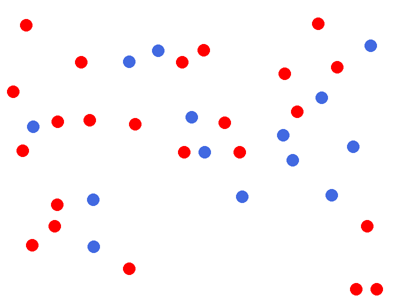

You answer a question about an image by interleaving Thought, Action, and Observation.
Available tools:
  describe[]            - one fresh full description of the image
  crop[x1,y1,x2,y2]     - re-look at a normalised box (0..1) of the image; returns a one-sentence description
  calc[expr]            - evaluate a numerical expression
  Finish[answer]        - emit the final concise answer and stop

Format strictly:
  Thought N: short reasoning
  Action N: tool_name[argument]
Use describe[] first to understand what is in the image. Use crop[] when you need to inspect a region (e.g. to count or verify a small detail).
Stop after at most 5 steps by emitting Finish[your answer].

Question: How many red dots and how many blue dots are in this image? Give the totals. Use crop[] to inspect quadrants if a single describe[] is not confident.

Thought 1: I need to count the red and blue dots in the image. I will start by describing the image to get an overall sense of the distribution.
Action 

In [8]:
img = look_at('images/dots.png')
disp = img.copy(); disp.thumbnail((400, 400))
from IPython.display import display
display(disp)
_ = react('How many red dots and how many blue dots are in this image? Give the totals. '
          'Use crop[] to inspect quadrants if a single describe[] is not confident.',
          VISION_TOOLS, VISION_SYSTEM,
          images=[img], max_steps=6)


## 8. Vision task 2 — receipt total

Read the receipt, sum the items via the calculator (rather than trusting the VLM's mental arithmetic), check it matches the printed total.

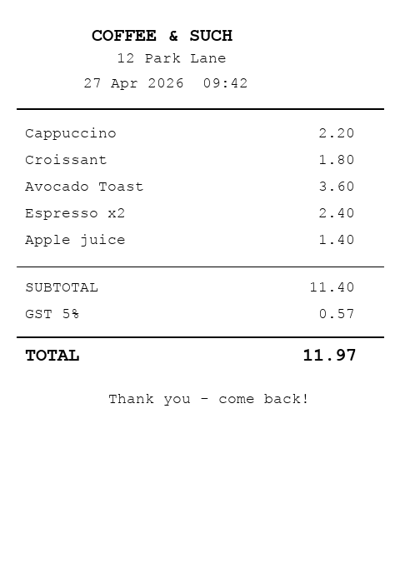

You answer a question about an image by interleaving Thought, Action, and Observation.
Available tools:
  describe[]            - one fresh full description of the image
  crop[x1,y1,x2,y2]     - re-look at a normalised box (0..1) of the image; returns a one-sentence description
  calc[expr]            - evaluate a numerical expression
  Finish[answer]        - emit the final concise answer and stop

Format strictly:
  Thought N: short reasoning
  Action N: tool_name[argument]
Use describe[] first to understand what is in the image. Use crop[] when you need to inspect a region (e.g. to count or verify a small detail).
Stop after at most 5 steps by emitting Finish[your answer].

Question: Read the items and prices on this receipt, compute the subtotal yourself with the calculator, and compare it to the printed subtotal. Report whether they match.

Thought 1: Action 1: describe[]观察结果：这是一张来自 "COFFEE & SUCH" 的收据。列出的项目包括：
- Cappuccino: 2.20
- Croissant: 1.80
- Avocado Toast: 3.60
- Espresso

In [9]:
img = look_at('images/receipt.png')
disp = img.copy(); disp.thumbnail((400, 600))
display(disp)
_ = react('Read the items and prices on this receipt, compute the subtotal yourself with the calculator, '
          'and compare it to the printed subtotal. Report whether they match.',
          VISION_TOOLS, VISION_SYSTEM,
          images=[img], max_steps=5)


## 9. Vision task 3 — multi-region inspection

A man doing planks in a gym. Is he wearing a watch? The full image is wide; the wrist region is small — a perfect ReAct case for `crop[]`.

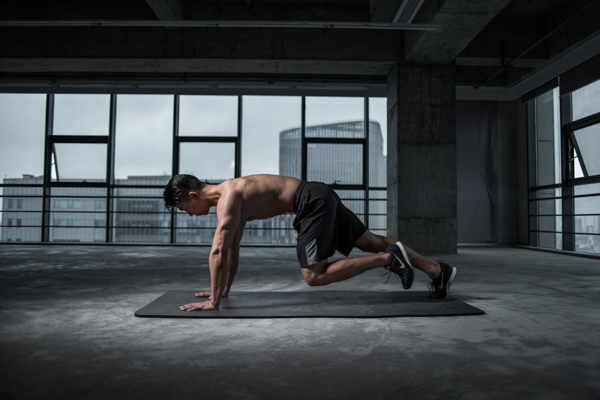

You answer a question about an image by interleaving Thought, Action, and Observation.
Available tools:
  describe[]            - one fresh full description of the image
  crop[x1,y1,x2,y2]     - re-look at a normalised box (0..1) of the image; returns a one-sentence description
  calc[expr]            - evaluate a numerical expression
  Finish[answer]        - emit the final concise answer and stop

Format strictly:
  Thought N: short reasoning
  Action N: tool_name[argument]
Use describe[] first to understand what is in the image. Use crop[] when you need to inspect a region (e.g. to count or verify a small detail).
Stop after at most 5 steps by emitting Finish[your answer].

Question: Is the person in this image wearing a wristwatch? Inspect the wrist region carefully before answering. Coordinates for crop[] are normalised 0..1 in the form x1,y1,x2,y2 (left,top,right,bottom).

Thought 1: Action 1: describe[]
Observation 1: A high-angle, full-shot photograph shows a muscular man perf

In [10]:
img = look_at('images/climber.jpg')
disp = img.copy(); disp.thumbnail((600, 400))
display(disp)
_ = react('Is the person in this image wearing a wristwatch? Inspect the wrist region carefully before '
          'answering. Coordinates for crop[] are normalised 0..1 in the form x1,y1,x2,y2 (left,top,right,bottom).',
          VISION_TOOLS, VISION_SYSTEM,
          images=[img], max_steps=5)



Four more demos with tools an applied-AI lab actually reaches for: a date-difference tool to fix Diwali properly, arXiv search for related-work workflows, a tabular Q&A tool over a sensor CSV, and a satellite kiln-counting task on a tile from **SentinelKilnDB** (Lucknow airshed, hand-validated OBB labels).

### Tool: `date_diff`

The Diwali run earlier got 195 days right but did the arithmetic *manually* — defeating the point of ReAct. Adding a real tool so the model can defer the calc.

In [11]:
def tool_date_diff(arg: str) -> str:
    """date_diff[YYYY-MM-DD, YYYY-MM-DD] -> integer days (signed)."""
    parts = [s.strip() for s in arg.split(',')]
    if len(parts) != 2:
        return 'date_diff expects "YYYY-MM-DD, YYYY-MM-DD"'
    d1 = datetime.date.fromisoformat(parts[0])
    d2 = datetime.date.fromisoformat(parts[1])
    return str((d2 - d1).days)

TEXT_TOOLS_V2 = {**TEXT_TOOLS, "date_diff": tool_date_diff}
TEXT_SYSTEM_V2 = TEXT_SYSTEM.replace(
    "today[]        - returns today's date as YYYY-MM-DD",
    ("today[]        - returns today's date as YYYY-MM-DD\n"
     "  date_diff[d1, d2] - returns integer days from d1 to d2 (both YYYY-MM-DD)"))

_ = react("How many days are there from today to Diwali 2026 (Nov 8, 2026)?",
          TEXT_TOOLS_V2, TEXT_SYSTEM_V2)


You answer the user's question by interleaving Thought, Action, and Observation steps.
Available tools:
  search[query]  - returns a short Wikipedia summary for the query
  calc[expr]     - returns the numerical value of a Python arithmetic expression (e.g. "23 * (1+0.05)**3")
  today[]        - returns today's date as YYYY-MM-DD
  date_diff[d1, d2] - returns integer days from d1 to d2 (both YYYY-MM-DD)
  Finish[answer] - emit the final concise answer and stop

Format strictly:
  Thought N: short reasoning
  Action N: tool_name[argument]
Always pick exactly one Action per step. Stop after at most 5 steps by emitting Finish[your answer].

Question: How many days are there from today to Diwali 2026 (Nov 8, 2026)?

Thought 1: Action 1: today[]
Observation 1: 2026-04-27
Thought 2: Action 2: date_diff[2026-04-27, 2026-11-08]
Observation 2: 195
Thought 3: Finish[195]

=> Final answer: 195


### arXiv search — related-work lookup

Given a topic, search arXiv for the most-recent relevant paper and return a short report. Useful for the "is there prior art for X?" workflow.

Class label `2` in SentinelKilnDB = Zigzag kiln (the post-2017 cleaner-tech variant). The question is loaded for our own lab — let's see if the model uses the right keywords.

In [12]:
import arxiv
_arxiv_client = arxiv.Client(page_size=5, num_retries=2)

def tool_arxiv(query: str) -> str:
    """arxiv[query] -> top hit: title, authors, year, arxiv id, 1-line abstract."""
    s = arxiv.Search(query=query, max_results=3,
                     sort_by=arxiv.SortCriterion.Relevance)
    out = []
    for r in _arxiv_client.results(s):
        auth = ", ".join(a.name for a in r.authors[:3])
        if len(r.authors) > 3: auth += " et al."
        abst = re.sub(r"\s+", " ", (r.summary or ""))[:280]
        out.append(f"- {r.title} ({r.published.year}) [{r.entry_id.rsplit('/', 1)[-1]}]\n  {auth}\n  {abst}")
    return "\n".join(out) if out else "no hits"

TEXT_TOOLS_V3 = {**TEXT_TOOLS_V2, "arxiv": tool_arxiv}
TEXT_SYSTEM_V3 = TEXT_SYSTEM_V2.replace(
    "  search[query]  - returns a short Wikipedia summary for the query",
    ("  search[query]  - returns a short Wikipedia summary for the query\n"
     "  arxiv[query]   - returns top arXiv hits with title, authors, year, id, abstract"))

Q_LAB = ("Find the recent benchmark dataset paper on satellite detection of brick kilns "
         "in South Asia. Report its title, authors, and year.")
_ = react(Q_LAB, TEXT_TOOLS_V3, TEXT_SYSTEM_V3, max_steps=4)


You answer the user's question by interleaving Thought, Action, and Observation steps.
Available tools:
  search[query]  - returns a short Wikipedia summary for the query
  arxiv[query]   - returns top arXiv hits with title, authors, year, id, abstract
  calc[expr]     - returns the numerical value of a Python arithmetic expression (e.g. "23 * (1+0.05)**3")
  today[]        - returns today's date as YYYY-MM-DD
  date_diff[d1, d2] - returns integer days from d1 to d2 (both YYYY-MM-DD)
  Finish[answer] - emit the final concise answer and stop

Format strictly:
  Thought N: short reasoning
  Action N: tool_name[argument]
Always pick exactly one Action per step. Stop after at most 5 steps by emitting Finish[your answer].

Question: Find the recent benchmark dataset paper on satellite detection of brick kilns in South Asia. Report its title, authors, and year.

Thought 1: I need to find a recent benchmark dataset paper specifically about satellite detection of brick kilns in South Asia. I w

### Tabular Q&A — sensor CSV

120 days of synthetic daily PM2.5 (µg/m³) and temperature for some hypothetical site. The `df_query` tool runs a single pandas-style aggregation; the model has to compose the right query.

In [13]:
import pandas as pd
df_air = pd.read_csv("images/airq.csv", parse_dates=["date"])

def tool_df_query(arg: str) -> str:
    """df_query[op, column, optional date filter] -> result.

    Examples:
        df_query[mean, pm25]
        df_query[max, pm25]
        df_query[mean, pm25, 2026-02-01..2026-02-28]
        df_query[count, pm25, >150]
        df_query[head, , 5]
    """
    parts = [p.strip() for p in arg.split(",")]
    if len(parts) < 2:
        return "df_query expects \"op, column[, filter]\""
    op, col = parts[0].lower(), parts[1]
    flt = parts[2] if len(parts) > 2 else None
    d = df_air
    if flt and ".." in flt:
        a, b = flt.split("..")
        d = d[(d.date >= a) & (d.date <= b)]
    elif flt and flt[:1] in "<>=":
        d = d.query(f"{col} {flt}")
    if op == "head":
        return d.head(int(flt or 5)).to_string(index=False)
    if op == "schema":
        return f"columns={list(d.columns)} rows={len(d)} date_range={d.date.min().date()}..{d.date.max().date()}"
    if not col or col not in d.columns:
        return f"unknown column {col!r}; have {list(d.columns)}"
    s = d[col]
    return {
        "mean": lambda: round(s.mean(), 2),
        "median": lambda: round(s.median(), 2),
        "max": lambda: f"{s.max():.2f} on {d.loc[s.idxmax(), 'date'].date()}",
        "min": lambda: f"{s.min():.2f} on {d.loc[s.idxmin(), 'date'].date()}",
        "count": lambda: int(len(s)),
        "std": lambda: round(s.std(), 2),
    }.get(op, lambda: f"unknown op {op!r}")()

TEXT_TOOLS_V4 = {**TEXT_TOOLS_V3, "df_query": tool_df_query}
TEXT_SYSTEM_V4 = TEXT_SYSTEM_V3.replace(
    "  arxiv[query]   - returns top arXiv hits with title, authors, year, id, abstract",
    ("  arxiv[query]   - returns top arXiv hits with title, authors, year, id, abstract\n"
     "  df_query[op, column[, filter]] - run an aggregation on the air-quality CSV\n"
     "    ops: mean, median, max, min, std, count, head, schema\n"
     "    optional filter: a date range (YYYY-MM-DD..YYYY-MM-DD) or a comparison (>150)"))

Q_CSV = ("Using the air-quality CSV (daily PM2.5 and temp), how many days had PM2.5 above the WHO 24-hour "
         "guideline of 15 µg/m³, and what was the worst day overall?")
_ = react(Q_CSV, TEXT_TOOLS_V4, TEXT_SYSTEM_V4, max_steps=5)


You answer the user's question by interleaving Thought, Action, and Observation steps.
Available tools:
  search[query]  - returns a short Wikipedia summary for the query
  arxiv[query]   - returns top arXiv hits with title, authors, year, id, abstract
  df_query[op, column[, filter]] - run an aggregation on the air-quality CSV
    ops: mean, median, max, min, std, count, head, schema
    optional filter: a date range (YYYY-MM-DD..YYYY-MM-DD) or a comparison (>150)
  calc[expr]     - returns the numerical value of a Python arithmetic expression (e.g. "23 * (1+0.05)**3")
  today[]        - returns today's date as YYYY-MM-DD
  date_diff[d1, d2] - returns integer days from d1 to d2 (both YYYY-MM-DD)
  Finish[answer] - emit the final concise answer and stop

Format strictly:
  Thought N: short reasoning
  Action N: tool_name[argument]
Always pick exactly one Action per step. Stop after at most 5 steps by emitting Finish[your answer].

Question: Using the air-quality CSV (daily PM2.5 and te

### Brick-kiln spotting on a SentinelKilnDB tile

A 640×640 Sentinel-2 RGB tile from the Lucknow airshed; the hand-validated OBB labels have **3 kilns** (2 Zigzag + 1 FCBK) clustered in the lower-right quadrant. The model should describe the scene, crop the suspicious area, and report a count.

Ground truth is loaded from the original `.txt` label so we can score the answer.

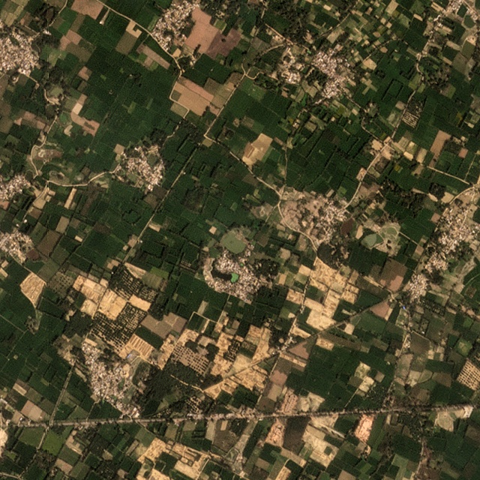

Ground truth: 3 kilns -> {'Zigzag': 2, 'FCBK': 1}
You answer a question about an image by interleaving Thought, Action, and Observation.
Available tools:
  describe[]            - one fresh full description of the image
  crop[x1,y1,x2,y2]     - re-look at a normalised box (0..1) of the image; returns a one-sentence description
  calc[expr]            - evaluate a numerical expression
  Finish[answer]        - emit the final concise answer and stop

Format strictly:
  Thought N: short reasoning
  Action N: tool_name[argument]
Use describe[] first to understand what is in the image. Use crop[] when you need to inspect a region (e.g. to count or verify a small detail).
Stop after at most 5 steps by emitting Finish[your answer].

Question: This is a 640x640 Sentinel-2 satellite tile from the Lucknow region, India. Brick kilns appear as small reddish-brown rectangular structures, often clustered. How many brick kilns can you identify in this tile? Use crop[] to inspect quadrants if you nee

In [14]:
img = look_at("images/kiln_tile.jpg")
disp = img.copy(); disp.thumbnail((480, 480))
display(disp)

KILN_NAMES = {0: "CFCBK", 1: "FCBK", 2: "Zigzag"}
gt = "2 0.576949 0.923212 0.590202 0.887280 0.572253 0.880650 0.558963 0.916583\n2 0.603564 0.861006 0.618820 0.819425 0.602472 0.813409 0.587217 0.855031\n1 0.755134 0.916951 0.777526 0.868577 0.762125 0.861456 0.739770 0.909830"
gt_count = {KILN_NAMES[int(line.split()[0])]: 0 for line in gt.strip().splitlines()}
for line in gt.strip().splitlines():
    gt_count[KILN_NAMES[int(line.split()[0])]] += 1
print("Ground truth:", sum(gt_count.values()), "kilns ->", gt_count)

_ = react("This is a 640x640 Sentinel-2 satellite tile from the Lucknow region, India. "
          "Brick kilns appear as small reddish-brown rectangular structures, often clustered. "
          "How many brick kilns can you identify in this tile? "
          "Use crop[] to inspect quadrants if you need a closer look.",
          VISION_TOOLS, VISION_SYSTEM,
          images=[img], max_steps=6)
